What is inside:

* full integrated PennyLane Lightning circuit
* wealth register
* 7 yearly shock registers
* year-3 and year-7 flag qubits
* success ancilla
* classical MC benchmark
* exact discrete benchmark
* direct probability extraction from the integrated oracle

Key design choice:

* to stay near your earlier 25-qubit target, I compressed the annual shock model from 8 buckets to 4 buckets
* with 6 wealth bits, that gives 23 total qubits, which is much more realistic for a running integrated simulation on lightning.qubit

So this is now much closer to the real architecture we discussed. The next step after this would be to wrap this oracle in a reduced AE routine. 

# Parametric PennyLane QAOA processor

This notebook reads the **Assets** sheet directly. All decision variables come from asset rows only.

Updates in this version:

- fully asset-row driven parametrization
- exact-mode export filtering to avoid Excel write blowups
- export controls exposed through Settings
- optional auto-disable for classical search on very large qubit counts

In [12]:
# !pip -q install yfinance openpyxl pandas numpy scipy matplotlib pennylane pennylane-lightning

In [13]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
from scipy.optimize import minimize

try:
    import yfinance as yf
except Exception:
    yf = None

try:
    import pennylane as qml
except Exception:
    qml = None

In [14]:
xlsx_path = Path("parametric_assets_only_input_extended.xlsx")

# Optional manual override for quick ad-hoc testing.
REFRESH_OVERRIDE = None
xlsx_path


PosixPath('parametric_assets_only_input_extended.xlsx')

In [15]:
def setting_value(settings, key, default=None):
    return settings[key] if key in settings and pd.notna(settings[key]) else default

def setting_bool(settings, key, default=False):
    val = setting_value(settings, key, default)
    if isinstance(val, str):
        val = val.strip().lower()
        if val in {"1", "true", "yes", "y", "on"}:
            return True
        if val in {"0", "false", "no", "n", "off"}:
            return False
    try:
        return bool(int(val))
    except Exception:
        return bool(val)

def setting_int(settings, key, default=0):
    val = setting_value(settings, key, default)
    try:
        return int(float(val))
    except Exception:
        return int(default)

def setting_float(settings, key, default=0.0):
    val = setting_value(settings, key, default)
    try:
        return float(val)
    except Exception:
        return float(default)

xls = pd.ExcelFile(xlsx_path)

assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
settings = dict(zip(settings_df["Key"], settings_df["Value"]))

display(assets_df.head())
display(settings_df)

,decision_id,Ticker,Company,Asset Group,Option Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,Current Price (USD),Mean Daily Return,Std Daily Return,Allowed,Price Source Status,Source URL
0,NVDA_opt1,NVDA,NVIDIA,NVDA,100k,498,100040.727264,0.979824,0.340606,200.884995,0.002964,0.021456,1,Imported via yfinance,https://pypi.org/project/yfinance/
1,NVDA_opt2,NVDA,NVIDIA,NVDA,150k,747,150061.090897,0.979824,0.340606,200.884995,0.002964,0.021456,1,Imported via yfinance,https://pypi.org/project/yfinance/
2,AAPL_opt1,AAPL,Apple,AAPL,100k,372,100033.817505,0.371104,0.235630,268.908112,0.001372,0.014843,1,Imported via yfinance,https://pypi.org/project/yfinance/
3,AAPL_opt2,AAPL,Apple,AAPL,150k,558,150050.726257,0.371104,0.235630,268.908112,0.001372,0.014843,1,Imported via yfinance,https://pypi.org/project/yfinance/
4,MSFT_opt1,MSFT,Microsoft,MSFT,100k,236,100143.554932,0.162612,0.245081,424.337097,0.000722,0.015439,1,Imported via yfinance,https://pypi.org/project/yfinance/


,Key,Value,Description
0,budget_usd,1000000,Target total budget
1,risk_free_rate_annual,0.04,Annual risk-free rate used in excess-return re...
2,lambda_budget,50,Budget deviation penalty
3,lambda_variance,6,Variance contribution weight
4,lambda_exclusive,0,Unused in current notebook; kept for transparency
5,top_n_export,20,Number of candidate portfolios exported to ove...
6,refresh_market_data,0,1 = refresh prices/returns/volatility from yfi...
7,enable_qaoa,1,"1 = run QAOA, 0 = skip QAOA"
8,qaoa_p,2,QAOA depth / number of layers
9,qaoa_maxiter,60,Optimizer iteration budget for QAOA


In [16]:
REFRESH_WITH_YFINANCE = setting_bool(settings, "refresh_market_data", False)
if REFRESH_OVERRIDE is not None:
    REFRESH_WITH_YFINANCE = bool(REFRESH_OVERRIDE)

TOP_N_EXPORT = setting_int(settings, "top_n_export", 20)
ENABLE_QAOA = setting_bool(settings, "enable_qaoa", True)
QAOA_P = setting_int(settings, "qaoa_p", 1)
QAOA_MAXITER = setting_int(settings, "qaoa_maxiter", 60)
QAOA_SHOTS = setting_int(settings, "qaoa_shots", 4096)
QAOA_EXACT_PROBABILITY_MAX_QUBITS = setting_int(settings, "qaoa_exact_probability_max_qubits", 20)
QAOA_MAX_QUBITS_ALLOWED = setting_int(settings, "qaoa_max_qubits_allowed", 24)

QAOA_EXPORT_MODE = str(setting_value(settings, "qaoa_export_mode", "top_k")).strip().lower()
if QAOA_EXPORT_MODE not in {"top_k", "all_filtered"}:
    QAOA_EXPORT_MODE = "top_k"
QAOA_MIN_PROBABILITY_TO_EXPORT = setting_float(settings, "qaoa_min_probability_to_export", 1e-12)
QAOA_MAX_EXPORT_ROWS = max(1, setting_int(settings, "qaoa_max_export_rows", 5000))
QAOA_EXPORT_FEASIBLE_ONLY = setting_bool(settings, "qaoa_export_feasible_only", False)
QAOA_FEASIBILITY_BUDGET_TOLERANCE_USD = setting_float(settings, "qaoa_feasibility_budget_tolerance_usd", 2500.0)
QAOA_EXPORT_SORT_BY = str(setting_value(settings, "qaoa_export_sort_by", "probability")).strip().lower()
if QAOA_EXPORT_SORT_BY not in {"probability", "qubo_value", "sharpe_like", "portfolio_return", "abs_budget_gap"}:
    QAOA_EXPORT_SORT_BY = "probability"

ENABLE_CLASSICAL_SEARCH = setting_bool(settings, "enable_classical_search", True)
CLASSICAL_MAX_QUBITS_ALLOWED = setting_int(settings, "classical_max_qubits_allowed", 30)
RANDOM_SEARCH_SAMPLES = setting_int(settings, "classical_random_search_samples", 8000)
LOCAL_SEARCH_STARTS = setting_int(settings, "classical_local_search_starts", 40)
CLASSICAL_MAX_NEIGHBOR_EVALS = setting_int(settings, "classical_max_neighbor_evals", 200000)

OVERVIEW_CLASSICAL_POOL = setting_int(settings, "overview_classical_pool", 300)
OVERVIEW_QAOA_POOL = setting_int(settings, "overview_qaoa_pool", 500)
RESULT_CANDIDATE_LIMIT_PER_SOLVER = setting_int(settings, "result_candidate_limit_per_solver", 500)
RNG_SEED = setting_int(settings, "rng_seed", 42)

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

budget_usd = setting_float(settings, "budget_usd", 1_000_000.0)
risk_free = setting_float(settings, "risk_free_rate_annual", 0.04)
lambda_budget = setting_float(settings, "lambda_budget", 50.0)
lambda_variance = setting_float(settings, "lambda_variance", 6.0)
lambda_exclusive = 0.0

print("Refresh with yfinance:", REFRESH_WITH_YFINANCE)
print("Enable QAOA:", ENABLE_QAOA)
print("Enable classical search:", ENABLE_CLASSICAL_SEARCH)
print("QAOA export mode:", QAOA_EXPORT_MODE)
print("QAOA export sort by:", QAOA_EXPORT_SORT_BY)


Refresh with yfinance: False
Enable QAOA: True
Enable classical search: True
QAOA export mode: top_k
QAOA export sort by: probability


In [17]:
if REFRESH_WITH_YFINANCE:
    if yf is None:
        raise ImportError("yfinance is required when refresh_market_data = 1.")
    option_rows = assets_df.loc[assets_df["Ticker"].notna()].copy()
    if "Allowed" in option_rows.columns:
        option_rows = option_rows.loc[option_rows["Allowed"].fillna(1).astype(int) == 1].copy()

    tickers = list(dict.fromkeys(option_rows["Ticker"].astype(str).tolist()))
    if len(tickers) == 0:
        raise ValueError("No tickers available to refresh.")

    prices = yf.download(
        tickers=tickers,
        period="12mo",
        interval="1d",
        auto_adjust=True,
        progress=False,
    )["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    prices = prices.dropna(how="all").ffill().dropna()
    rets = prices.pct_change().dropna()

    total_return_12m = prices.iloc[-1] / prices.iloc[0] - 1
    ann_vol = rets.std() * np.sqrt(252)
    mean_daily = rets.mean()
    std_daily = rets.std()
    daily_cov = rets.cov()
    annual_cov = daily_cov * 252
    latest_price = prices.iloc[-1]

    wb = load_workbook(xlsx_path)
    sh_assets = wb["Assets"]
    sh_returns = wb["Returns"]
    sh_cov = wb["Covariance"]
    sh_acov = wb["AnnualizedCovariance"]
    sh_ph = wb["PriceHistory"]

    asset_headers = [sh_assets.cell(2, c).value for c in range(1, sh_assets.max_column + 1)]
    col_idx = {h: i + 1 for i, h in enumerate(asset_headers)}

    # Clear and rewrite price history
    for row in sh_ph.iter_rows(min_row=3, max_row=max(sh_ph.max_row, 5000), min_col=1, max_col=1 + len(tickers)):
        for cell in row:
            cell.value = None

    for r_idx, dt in enumerate(prices.index, start=3):
        sh_ph.cell(r_idx, 1, dt.to_pydatetime())
        for c_idx, t in enumerate(tickers, start=2):
            sh_ph.cell(r_idx, c_idx, float(prices.loc[dt, t]))

    # Update per-option rows in Assets
    for r_idx in range(3, sh_assets.max_row + 1):
        ticker = sh_assets.cell(r_idx, col_idx["Ticker"]).value
        if not ticker or ticker not in latest_price.index:
            continue

        sh_assets.cell(r_idx, col_idx["Current Price (USD)"], float(latest_price[ticker]))
        sh_assets.cell(r_idx, col_idx["Expected Return Proxy"], float(total_return_12m[ticker]))
        sh_assets.cell(r_idx, col_idx["Annual Volatility"], float(ann_vol[ticker]))

        if "Mean Daily Return" in col_idx:
            sh_assets.cell(r_idx, col_idx["Mean Daily Return"], float(mean_daily[ticker]))
        if "Std Daily Return" in col_idx:
            sh_assets.cell(r_idx, col_idx["Std Daily Return"], float(std_daily[ticker]))
        if "Price Source Status" in col_idx:
            sh_assets.cell(r_idx, col_idx["Price Source Status"], "Refreshed with yfinance")
        if "Source URL" in col_idx:
            sh_assets.cell(r_idx, col_idx["Source URL"], "https://pypi.org/project/yfinance/")

        # If Shares is present, refresh Approx Cost USD from Shares × Current Price.
        if "Shares" in col_idx and "Approx Cost USD" in col_idx:
            shares = sh_assets.cell(r_idx, col_idx["Shares"]).value
            try:
                if shares is not None and not pd.isna(shares):
                    sh_assets.cell(r_idx, col_idx["Approx Cost USD"], float(shares) * float(latest_price[ticker]))
            except Exception:
                pass

    # Update per-ticker returns sheet
    for row in sh_returns.iter_rows(min_row=3, max_row=max(sh_returns.max_row, 5000), min_col=1, max_col=6):
        for cell in row:
            cell.value = None

    for idx, ticker in enumerate(tickers, start=3):
        sh_returns.cell(idx, 1, ticker)
        sh_returns.cell(idx, 2, float(total_return_12m[ticker]))
        sh_returns.cell(idx, 3, float(ann_vol[ticker]))
        sh_returns.cell(idx, 4, float(mean_daily[ticker]))
        sh_returns.cell(idx, 5, float(std_daily[ticker]))
        sh_returns.cell(idx, 6, "Refreshed with yfinance")

    # Update covariance matrices
    for i, tr in enumerate(tickers, start=3):
        sh_cov.cell(i, 1, tr)
        sh_acov.cell(i, 1, tr)
        for j, tc in enumerate(tickers, start=2):
            sh_cov.cell(2, j, tc)
            sh_acov.cell(2, j, tc)
            sh_cov.cell(i, j, float(daily_cov.loc[tr, tc]))
            sh_acov.cell(i, j, float(annual_cov.loc[tr, tc]))

    wb.save(xlsx_path)

    # Reload
    xls = pd.ExcelFile(xlsx_path)
    assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
    settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
    settings = dict(zip(settings_df["Key"], settings_df["Value"]))

    print(f"Workbook refreshed and saved to {xlsx_path.resolve()}")

In [18]:
options_df = assets_df.loc[assets_df["Ticker"].notna()].copy()
options_df["Ticker"] = options_df["Ticker"].astype(str)

if "Allowed" in options_df.columns:
    options_df = options_df.loc[options_df["Allowed"].fillna(1).astype(int) == 1].copy()

required_option_cols = ["Ticker", "Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]
missing_option_cols = [c for c in required_option_cols if c not in options_df.columns]
if missing_option_cols:
    raise ValueError(
        "Assets sheet must define the selectable options directly. "
        f"Missing required columns: {missing_option_cols}"
    )

for col in ["Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]:
    options_df[col] = pd.to_numeric(options_df[col], errors="coerce")

if options_df["Approx Cost USD"].isna().any():
    bad = options_df.loc[options_df["Approx Cost USD"].isna(), "Ticker"].tolist()
    raise ValueError(f"Approx Cost USD missing for options: {bad}")

if (options_df["Approx Cost USD"] <= 0).any():
    bad = options_df.loc[options_df["Approx Cost USD"] <= 0, ["Ticker", "Approx Cost USD"]]
    raise ValueError(f"Approx Cost USD must be > 0 for all options. Bad rows:\n{bad}")

if "decision_id" not in options_df.columns:
    options_df["decision_id"] = [f"{ticker}_opt{i+1}" for i, ticker in enumerate(options_df["Ticker"].tolist())]
else:
    options_df["decision_id"] = options_df["decision_id"].astype(str)

if "Company" not in options_df.columns:
    options_df["Company"] = options_df["Ticker"]

if "Option Label" not in options_df.columns:
    options_df["Option Label"] = ""

if "Shares" not in options_df.columns:
    options_df["Shares"] = np.nan

if "Asset Group" not in options_df.columns:
    options_df["Asset Group"] = options_df["Ticker"]

options_df = options_df.reset_index(drop=True)

annual_cov_df = pd.read_excel(xls, sheet_name="AnnualizedCovariance", header=1)
annual_cov_df = annual_cov_df.rename(columns={annual_cov_df.columns[0]: "Ticker"})
annual_cov_df = annual_cov_df.loc[annual_cov_df["Ticker"].notna()].copy()
annual_cov_df["Ticker"] = annual_cov_df["Ticker"].astype(str)
annual_cov_df = annual_cov_df.set_index("Ticker")

asset_universe = list(dict.fromkeys(options_df["Ticker"].tolist()))
missing_cov_assets = [t for t in asset_universe if t not in annual_cov_df.index or t not in annual_cov_df.columns]
if missing_cov_assets:
    raise ValueError(
        "AnnualizedCovariance sheet is missing these tickers used by the options: "
        + ", ".join(missing_cov_assets)
    )

Sigma_assets = annual_cov_df.loc[asset_universe, asset_universe].to_numpy(dtype=float)
ticker_to_idx = {t: i for i, t in enumerate(asset_universe)}

decision_ids = options_df["decision_id"].tolist()
opt_tickers = options_df["Ticker"].tolist()
opt_cost = options_df["Approx Cost USD"].astype(float).to_numpy()
opt_ret = options_df["Expected Return Proxy"].astype(float).to_numpy()
option_asset_groups = options_df["Asset Group"].astype(str).tolist()

n = len(options_df)
Sigma_opt = np.zeros((n, n), dtype=float)
for i in range(n):
    ai = ticker_to_idx[opt_tickers[i]]
    for j in range(n):
        aj = ticker_to_idx[opt_tickers[j]]
        Sigma_opt[i, j] = Sigma_assets[ai, aj]

if ENABLE_QAOA and n > QAOA_MAX_QUBITS_ALLOWED:
    print(
        f"QAOA auto-disabled: n={n} exceeds qaoa_max_qubits_allowed={QAOA_MAX_QUBITS_ALLOWED}. "
        "You can raise the threshold in Settings, but statevector simulation may become infeasible."
    )
    ENABLE_QAOA = False

print(f"Assets referenced by options: {len(asset_universe)}")
print(f"Decision variables from Excel: {n}")
print(f"QAOA layers p: {QAOA_P}")
display(options_df.head(10))

if ENABLE_CLASSICAL_SEARCH and n > CLASSICAL_MAX_QUBITS_ALLOWED:
    print(
        f"Classical search auto-disabled: n={n} exceeds classical_max_qubits_allowed={CLASSICAL_MAX_QUBITS_ALLOWED}. "
        "You can raise the threshold in Settings, but large neighborhood searches may become too slow."
    )
    ENABLE_CLASSICAL_SEARCH = False


Assets referenced by options: 12
Decision variables from Excel: 24
QAOA layers p: 2


,decision_id,Ticker,Company,Asset Group,Option Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,Current Price (USD),Mean Daily Return,Std Daily Return,Allowed,Price Source Status,Source URL
0,NVDA_opt1,NVDA,NVIDIA,NVDA,100k,498,100040.727264,0.979824,0.340606,200.884995,0.002964,0.021456,1,Imported via yfinance,https://pypi.org/project/yfinance/
1,NVDA_opt2,NVDA,NVIDIA,NVDA,150k,747,150061.090897,0.979824,0.340606,200.884995,0.002964,0.021456,1,Imported via yfinance,https://pypi.org/project/yfinance/
2,AAPL_opt1,AAPL,Apple,AAPL,100k,372,100033.817505,0.371104,0.235630,268.908112,0.001372,0.014843,1,Imported via yfinance,https://pypi.org/project/yfinance/
3,AAPL_opt2,AAPL,Apple,AAPL,150k,558,150050.726257,0.371104,0.235630,268.908112,0.001372,0.014843,1,Imported via yfinance,https://pypi.org/project/yfinance/
4,MSFT_opt1,MSFT,Microsoft,MSFT,100k,236,100143.554932,0.162612,0.245081,424.337097,0.000722,0.015439,1,Imported via yfinance,https://pypi.org/project/yfinance/
5,MSFT_opt2,MSFT,Microsoft,MSFT,150k,353,149790.995300,0.162612,0.245081,424.337097,0.000722,0.015439,1,Imported via yfinance,https://pypi.org/project/yfinance/
6,AVGO_opt1,AVGO,Broadcom,AVGO,100k,248,99993.603027,1.377139,0.427222,403.200012,0.003827,0.026912,1,Imported via yfinance,https://pypi.org/project/yfinance/
7,AVGO_opt2,AVGO,Broadcom,AVGO,150k,372,149990.404541,1.377139,0.427222,403.200012,0.003827,0.026912,1,Imported via yfinance,https://pypi.org/project/yfinance/
8,MU_opt1,MU,Micron Technology,MU,100k,218,99996.602661,5.683110,0.589606,458.700012,0.008309,0.037142,1,Imported via yfinance,https://pypi.org/project/yfinance/
9,MU_opt2,MU,Micron Technology,MU,150k,327,149994.903992,5.683110,0.589606,458.700012,0.008309,0.037142,1,Imported via yfinance,https://pypi.org/project/yfinance/


In [19]:
def build_qubo_budget_first(opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
                             lambda_budget, lambda_variance, lambda_exclusive, opt_tickers):
    n = len(opt_ret)
    Q = np.zeros((n, n), dtype=float)

    scaled_cost = opt_cost / float(budget_usd)

    ret_excess = opt_ret - risk_free
    ret_scale = np.max(np.abs(ret_excess)) + 1e-12
    ret_scaled = ret_excess / ret_scale

    sigma_scale = np.max(np.abs(Sigma_opt)) + 1e-12
    Sigma_scaled = Sigma_opt / sigma_scale

    reward = ret_scaled * scaled_cost
    for i in range(n):
        Q[i, i] += -reward[i]

    for i in range(n):
        Q[i, i] += lambda_variance * (scaled_cost[i] ** 2) * Sigma_scaled[i, i]
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_variance * scaled_cost[i] * scaled_cost[j] * Sigma_scaled[i, j]

    for i in range(n):
        Q[i, i] += lambda_budget * (scaled_cost[i] ** 2 - 2.0 * scaled_cost[i])
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_budget * scaled_cost[i] * scaled_cost[j]
    constant = float(lambda_budget)

    lambda_exclusive_effective = 0.0

    qubo_meta = {
        "scaled_cost": scaled_cost,
        "ret_scaled": ret_scaled,
        "Sigma_scaled": Sigma_scaled,
        "lambda_budget": float(lambda_budget),
        "lambda_variance": float(lambda_variance),
        "lambda_exclusive": float(lambda_exclusive_effective),
        "opt_tickers": list(opt_tickers),
        "budget_usd": float(budget_usd),
        "ret_scale": float(ret_scale),
        "sigma_scale": float(sigma_scale),
    }

    return Q, constant, qubo_meta

Q, constant, qubo_meta = build_qubo_budget_first(
    opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
    lambda_budget, lambda_variance, lambda_exclusive, opt_tickers
)

pd.DataFrame(Q, index=decision_ids, columns=decision_ids).iloc[:10, :10]

,NVDA_opt1,NVDA_opt2,AAPL_opt1,AAPL_opt2,MSFT_opt1,MSFT_opt2,AVGO_opt1,AVGO_opt2,MU_opt1,MU_opt2
NVDA_opt1,-9.503179,1.552665,1.007724,1.511586,1.012204,1.514018,1.026005,1.539007,1.029162,1.543743
NVDA_opt2,0.000000,-13.866602,1.511586,2.267378,1.518307,2.271026,1.539007,2.308511,1.543743,2.315615
AAPL_opt1,0.000000,0.000000,-9.500708,1.525631,1.004738,1.502849,1.007463,1.511195,1.007675,1.511512
AAPL_opt2,0.000000,0.000000,0.000000,-13.869654,1.507107,2.254274,1.511195,2.266792,1.511512,2.267268
MSFT_opt1,0.000000,0.000000,0.000000,0.000000,-9.506199,1.526674,1.012111,1.518166,1.008824,1.513235
MSFT_opt2,0.000000,0.000000,0.000000,0.000000,0.000000,-13.840583,1.513878,2.270816,1.508961,2.263441
AVGO_opt1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.496166,1.580664,1.033176,1.549764
AVGO_opt2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.849082,1.549764,2.324646
MU_opt1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.548353,1.653911
MU_opt2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.909052


In [20]:
def qubo_value(bitvec, Q, constant=0.0):
    x = np.asarray(bitvec, dtype=float)
    return float(x @ Q @ x + constant)

def qubo_term_breakdown(bitvec, qubo_meta):
    x = np.asarray(bitvec, dtype=float)

    scaled_cost = np.asarray(qubo_meta["scaled_cost"], dtype=float)
    ret_scaled = np.asarray(qubo_meta["ret_scaled"], dtype=float)
    Sigma_scaled = np.asarray(qubo_meta["Sigma_scaled"], dtype=float)
    lambda_budget = float(qubo_meta["lambda_budget"])
    lambda_variance = float(qubo_meta["lambda_variance"])

    num_selected = int(x.sum())

    return_term = float(-np.dot(ret_scaled * scaled_cost, x))
    weighted = x * scaled_cost
    risk_term = float(lambda_variance * (weighted @ Sigma_scaled @ weighted))
    budget_term = float(lambda_budget * (weighted.sum() - 1.0) ** 2)
    exclusivity_term = 0.0

    total = float(return_term + risk_term + budget_term + exclusivity_term)

    denom = max(num_selected, 1)
    return {
        "return_term": return_term,
        "risk_term": risk_term,
        "budget_term": budget_term,
        "exclusivity_term": exclusivity_term,
        "qubo_reconstructed": total,
        "avg_return_term_per_option": float(return_term / denom),
        "avg_risk_term_per_option": float(risk_term / denom),
        "avg_budget_term_per_option": float(budget_term / denom),
        "avg_exclusivity_term_per_option": 0.0,
    }

def portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    x = np.asarray(bitvec, dtype=float)
    selected_cost = x * opt_cost
    total = float(selected_cost.sum())
    num_selected = int(x.sum())

    if total <= 0:
        return {
            "selected_usd": 0.0,
            "budget_gap": -budget_usd,
            "abs_budget_gap": abs(-budget_usd),
            "num_options": 0,
            "num_distinct_assets": 0,
            "portfolio_return": 0.0,
            "portfolio_vol": 0.0,
            "sharpe_like": np.nan,
            "max_position_usd": 0.0,
        }

    weights = selected_cost / total
    port_ret = float(np.dot(weights, opt_ret))
    port_var = float(weights @ Sigma_opt @ weights)
    port_vol = float(np.sqrt(max(port_var, 0.0)))
    sharpe = np.nan if port_vol == 0 else (port_ret - risk_free) / port_vol
    distinct_assets = len(set([opt_tickers[i] for i, b in enumerate(x) if b > 0.5]))
    max_position = float(selected_cost.max())
    budget_gap = total - budget_usd

    return {
        "selected_usd": total,
        "budget_gap": budget_gap,
        "abs_budget_gap": abs(budget_gap),
        "num_options": num_selected,
        "num_distinct_assets": distinct_assets,
        "portfolio_return": port_ret,
        "portfolio_vol": port_vol,
        "sharpe_like": sharpe,
        "max_position_usd": max_position,
    }



def row_is_feasible(stats, tolerance_usd):
    return float(stats.get("abs_budget_gap", np.inf)) <= float(tolerance_usd)

def qaoa_export_priority(row, sort_by):
    if sort_by == "probability":
        return float(row.get("probability", 0.0))
    if sort_by == "qubo_value":
        return -float(row.get("qubo_value", np.inf))
    if sort_by == "sharpe_like":
        val = row.get("sharpe_like", np.nan)
        return -1e99 if pd.isna(val) else float(val)
    if sort_by == "portfolio_return":
        return float(row.get("portfolio_return", -np.inf))
    if sort_by == "abs_budget_gap":
        return -float(row.get("abs_budget_gap", np.inf))
    return float(row.get("probability", 0.0))

def sort_qaoa_export(df: pd.DataFrame, sort_by: str) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=candidate_cols)

    df = df.copy()
    if sort_by == "probability":
        primary, asc = "probability", False
    elif sort_by == "qubo_value":
        primary, asc = "qubo_value", True
    elif sort_by == "sharpe_like":
        primary, asc = "sharpe_like", False
    elif sort_by == "portfolio_return":
        primary, asc = "portfolio_return", False
    elif sort_by == "abs_budget_gap":
        primary, asc = "abs_budget_gap", True
    else:
        primary, asc = "probability", False

    sort_cols = []
    ascending = []

    if primary in df.columns:
        sort_cols.append(primary)
        ascending.append(asc)
    if "qubo_value" in df.columns and primary != "qubo_value":
        sort_cols.append("qubo_value")
        ascending.append(True)
    if "abs_budget_gap" in df.columns and primary != "abs_budget_gap":
        sort_cols.append("abs_budget_gap")
        ascending.append(True)
    if "probability" in df.columns and primary != "probability":
        sort_cols.append("probability")
        ascending.append(False)
    if "portfolio_return" in df.columns and primary != "portfolio_return":
        sort_cols.append("portfolio_return")
        ascending.append(False)
    if "bitstring" in df.columns:
        sort_cols.append("bitstring")
        ascending.append(True)

    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

def exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, qubo_meta, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    term_stats = qubo_term_breakdown(bitvec, qubo_meta)
    stats = portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    rows = []
    for idx, flag in enumerate(bitvec):
        if flag != 1:
            continue
        row = {
            "rank": rank,
            "source": source,
            "bitstring": bitstring,
            "Ticker": blocks_df.loc[idx, "Ticker"],
            "Company": blocks_df.loc[idx, "Company"] if "Company" in blocks_df.columns else blocks_df.loc[idx, "Ticker"],
            "Option Label": blocks_df.loc[idx, "Option Label"] if "Option Label" in blocks_df.columns else "",
            "Shares": blocks_df.loc[idx, "Shares"] if "Shares" in blocks_df.columns else np.nan,
            "Approx Cost USD": float(blocks_df.loc[idx, "Approx Cost USD"]),
            "Expected Return Proxy": float(blocks_df.loc[idx, "Expected Return Proxy"]),
            "Annual Volatility": float(blocks_df.loc[idx, "Annual Volatility"]),
            "decision_id": blocks_df.loc[idx, "decision_id"],
            **term_stats,
            **stats,
            "qubo_value": qubo_value(bitvec, Q, constant),
        }
        rows.append(row)
    return rows

In [21]:
def sort_candidates(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()

    df = df.copy()

    sort_cols = []
    ascending = []

    if "qubo_value" in df.columns:
        sort_cols.append("qubo_value")
        ascending.append(True)

    if "abs_budget_gap" in df.columns:
        sort_cols.append("abs_budget_gap")
        ascending.append(True)

    if "portfolio_return" in df.columns:
        sort_cols.append("portfolio_return")
        ascending.append(False)

    if "bitstring" in df.columns:
        sort_cols.append("bitstring")
        ascending.append(True)

    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

def random_solution(n):
    return np.random.randint(0, 2, size=n, dtype=int)

def greedy_improve_unconstrained(x, Q, constant, max_neighbor_evals=200000):
    x = x.copy()
    improved = True
    neighbor_evals = 0
    while improved and neighbor_evals < max_neighbor_evals:
        improved = False
        current_val = qubo_value(x, Q, constant)
        for i in range(len(x)):
            if neighbor_evals >= max_neighbor_evals:
                break
            y = x.copy()
            y[i] = 1 - y[i]
            y_val = qubo_value(y, Q, constant)
            neighbor_evals += 1
            if y_val < current_val - 1e-9:
                x = y
                current_val = y_val
                improved = True
    return x

candidate_cols = [
    "bitstring", "source", "probability", "qubo_value",
    "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
    "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
    "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
    "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
]

if ENABLE_CLASSICAL_SEARCH:
    candidate_dict = {}
    for _ in range(max(RANDOM_SEARCH_SAMPLES, 0)):
        x = random_solution(n)
        x = greedy_improve_unconstrained(x, Q, constant, CLASSICAL_MAX_NEIGHBOR_EVALS)
        bitstring = "".join(map(str, x.astype(int)))
        stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
        term_stats = qubo_term_breakdown(x, qubo_meta)
        candidate_dict[bitstring] = {
            "bitstring": bitstring,
            "source": "classical_heuristic",
            "probability": np.nan,
            "qubo_value": qubo_value(x, Q, constant),
            **term_stats,
            **stats
        }

    for start_idx in range(min(n, max(LOCAL_SEARCH_STARTS, 0))):
        x = np.zeros(n, dtype=int)
        x[start_idx] = 1
        x = greedy_improve_unconstrained(x, Q, constant, CLASSICAL_MAX_NEIGHBOR_EVALS)
        bitstring = "".join(map(str, x.astype(int)))
        stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
        term_stats = qubo_term_breakdown(x, qubo_meta)
        candidate_dict[bitstring] = {
            "bitstring": bitstring,
            "source": "classical_heuristic",
            "probability": np.nan,
            "qubo_value": qubo_value(x, Q, constant),
            **term_stats,
            **stats
        }

    classical_results = sort_candidates(pd.DataFrame(candidate_dict.values()))
else:
    classical_results = pd.DataFrame(columns=candidate_cols)

display(classical_results.head(20))
print("Classical candidate count:", len(classical_results))

,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,111111100000000000010000,classical_heuristic,NaN,0.476629,-0.099350,0.575978,7.849529e-07,0.0,0.476629,-0.012419,...,0.0,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897
1,010111100000100000011000,classical_heuristic,NaN,0.557828,-0.147247,0.705075,6.565252e-08,0.0,0.557828,-0.018406,...,0.0,1.000036e+06,36.236038,36.236038,8,7,0.870903,0.218490,3.802939,150061.090897
2,001110011100000000110000,classical_heuristic,NaN,0.562913,-0.325547,0.888457,2.598692e-06,0.0,0.562913,-0.040693,...,0.0,1.000228e+06,227.977722,227.977722,8,5,1.876679,0.245216,7.490055,150050.726257
3,111111100000000000100000,classical_heuristic,NaN,0.567778,-0.094717,0.538103,1.243922e-01,0.0,0.567778,-0.011840,...,0.0,9.501217e+05,-49878.297684,49878.297684,8,5,0.602557,0.200901,2.800166,150061.090897
4,111111100100000000000000,classical_heuristic,NaN,0.569859,-0.235445,0.805304,5.986278e-07,0.0,0.569859,-0.029431,...,0.0,1.000109e+06,109.419174,109.419174,8,5,1.368499,0.233486,5.689835,150061.090897
5,011101000000101000010010,classical_heuristic,NaN,0.571195,-0.180700,0.751885,9.441138e-06,0.0,0.571195,-0.022587,...,0.0,9.995655e+05,-434.537399,434.537399,8,7,1.060151,0.225732,4.519297,150061.090897
6,111110001000000001010000,classical_heuristic,NaN,0.572005,-0.242303,0.814301,6.862393e-06,0.0,0.572005,-0.030288,...,0.0,1.000370e+06,370.469772,370.469772,8,6,1.406838,0.234726,5.823130,150061.090897
7,111111100000000000000100,classical_heuristic,NaN,0.577430,-0.134722,0.712149,2.833101e-06,0.0,0.577430,-0.016840,...,0.0,1.000238e+06,238.037857,238.037857,8,5,0.800071,0.219539,3.462128,150123.522675
8,111101000000000001101000,classical_heuristic,NaN,0.578009,-0.171600,0.749608,5.006238e-07,0.0,0.578009,-0.021450,...,0.0,1.000100e+06,100.062363,100.062363,8,6,1.008262,0.225270,4.298234,150061.090897
9,111111100000000000000001,classical_heuristic,NaN,0.587617,-0.131920,0.719511,2.581727e-05,0.0,0.587617,-0.016490,...,0.0,1.000719e+06,718.571823,718.571823,8,5,0.783906,0.220565,3.372735,150604.056641


Classical candidate count: 5668


In [22]:
samples_df = pd.DataFrame(columns=candidate_cols)

history_columns = ["iteration"]
history_columns += [f"gamma_{i+1}" for i in range(QAOA_P)]
history_columns += [f"beta_{i+1}" for i in range(QAOA_P)]
history_columns += ["energy", "best_energy", "elapsed_sec"]
history_df = pd.DataFrame(columns=history_columns)

best_gammas = np.full(QAOA_P, np.nan, dtype=float)
best_betas = np.full(QAOA_P, np.nan, dtype=float)
qaoa_mode = "disabled"
qaoa_total_nonzero_states = 0
qaoa_total_states_considered = 0

if ENABLE_QAOA:
    import heapq

    def qubo_to_ising(Q, constant=0.0):
        n = Q.shape[0]
        h = np.zeros(n, dtype=float)
        J = {}
        offset = float(constant)
        for i in range(n):
            qii = Q[i, i]
            offset += qii / 2
            h[i] += -qii / 2
        for i in range(n):
            for j in range(i + 1, n):
                qij = Q[i, j]
                if abs(qij) > 1e-12:
                    offset += qij / 4
                    h[i] += -qij / 4
                    h[j] += -qij / 4
                    J[(i, j)] = qij / 4
        return h, J, offset

    h, J, ising_offset = qubo_to_ising(Q, constant)

    coeffs = []
    ops = []
    for i, coeff in enumerate(h):
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i))
    for (i, j), coeff in J.items():
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    if not coeffs:
        coeffs = [0.0]
        ops = [qml.Identity(0)]

    H = qml.Hamiltonian(coeffs, ops)

    exact_mode = n <= QAOA_EXACT_PROBABILITY_MAX_QUBITS
    qaoa_mode = "exact_probs" if exact_mode else f"shots_{QAOA_SHOTS}"
    dev = qml.device("lightning.qubit", wires=n, shots=None if exact_mode else QAOA_SHOTS)

    def apply_qaoa_layer(gamma, beta):
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-12:
                qml.RZ(2 * gamma * coeff, wires=i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-12:
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * gamma * coeff, wires=j)
                qml.CNOT(wires=[i, j])
        for w in range(n):
            qml.RX(2 * beta, wires=w)

    @qml.qnode(dev, interface="autograd")
    def qaoa_energy(params):
        gammas = params[:QAOA_P]
        betas = params[QAOA_P:]
        for w in range(n):
            qml.Hadamard(wires=w)
        for layer in range(QAOA_P):
            apply_qaoa_layer(gammas[layer], betas[layer])
        return qml.expval(H)

    if exact_mode:
        @qml.qnode(dev, interface="autograd")
        def qaoa_probs(params):
            gammas = params[:QAOA_P]
            betas = params[QAOA_P:]
            for w in range(n):
                qml.Hadamard(wires=w)
            for layer in range(QAOA_P):
                apply_qaoa_layer(gammas[layer], betas[layer])
            return qml.probs(wires=range(n))
    else:
        @qml.qnode(dev, interface="autograd")
        def qaoa_samples(params):
            gammas = params[:QAOA_P]
            betas = params[QAOA_P:]
            for w in range(n):
                qml.Hadamard(wires=w)
            for layer in range(QAOA_P):
                apply_qaoa_layer(gammas[layer], betas[layer])
            return qml.sample(wires=range(n))

    progress_rows = []
    start_time = time.time()

    def objective_logged(x):
        energy = float(qaoa_energy(x))
        elapsed = time.time() - start_time
        current_best = min([energy] + [r["energy"] for r in progress_rows]) if progress_rows else energy

        row = {"iteration": len(progress_rows) + 1}
        for i in range(QAOA_P):
            row[f"gamma_{i+1}"] = float(x[i])
        for i in range(QAOA_P):
            row[f"beta_{i+1}"] = float(x[QAOA_P + i])
        row["energy"] = energy
        row["best_energy"] = current_best
        row["elapsed_sec"] = elapsed
        progress_rows.append(row)

        gamma_str = "  ".join([f"g{i+1}={x[i]: .5f}" for i in range(QAOA_P)])
        beta_str = "  ".join([f"b{i+1}={x[QAOA_P+i]: .5f}" for i in range(QAOA_P)])
        print(
            f"iter={len(progress_rows):>3}  {gamma_str}  {beta_str}  "
            f"energy={energy: .6f}  best={current_best: .6f}  elapsed={elapsed: .1f}s"
        )
        return energy

    gamma_init = np.linspace(0.30, 0.60, QAOA_P)
    beta_init = np.linspace(0.40, 0.20, QAOA_P)
    x0 = np.concatenate([gamma_init, beta_init]).astype(float)

    res = minimize(objective_logged, x0=x0, method="COBYLA", options={"maxiter": QAOA_MAXITER})
    best_gammas = np.array(res.x[:QAOA_P], dtype=float)
    best_betas = np.array(res.x[QAOA_P:], dtype=float)
    history_df = pd.DataFrame(progress_rows)

    q_rows = []
    params_opt = np.concatenate([best_gammas, best_betas])

    if exact_mode:
        probs = np.array(qaoa_probs(params_opt))
        qaoa_total_states_considered = int(len(probs))
        qaoa_total_nonzero_states = int(np.count_nonzero(probs > 0))

        exact_heap = []
        exact_counter = 0

        for idx, prob in enumerate(probs):
            if prob < QAOA_MIN_PROBABILITY_TO_EXPORT:
                continue

            bitstring = format(idx, f"0{n}b")[::-1]
            bits = np.array(list(map(int, bitstring)), dtype=int)
            stats = portfolio_stats(bits, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)

            if QAOA_EXPORT_FEASIBLE_ONLY and not row_is_feasible(stats, QAOA_FEASIBILITY_BUDGET_TOLERANCE_USD):
                continue

            term_stats = qubo_term_breakdown(bits, qubo_meta)
            row = {
                "bitstring": "".join(map(str, bits.astype(int))),
                "source": f"qaoa_full_pennylane_p{QAOA_P}",
                "probability": float(prob),
                "qubo_value": qubo_value(bits, Q, constant),
                **term_stats,
                **stats
            }

            if QAOA_EXPORT_MODE == "all_filtered":
                q_rows.append(row)
            else:
                priority = qaoa_export_priority(row, QAOA_EXPORT_SORT_BY)
                payload = (priority, exact_counter, row)
                if len(exact_heap) < QAOA_MAX_EXPORT_ROWS:
                    heapq.heappush(exact_heap, payload)
                else:
                    if priority > exact_heap[0][0]:
                        heapq.heapreplace(exact_heap, payload)
                exact_counter += 1

        if QAOA_EXPORT_MODE == "top_k":
            q_rows = [item[2] for item in exact_heap]

    else:
        raw_samples = np.asarray(qaoa_samples(params_opt))
        if raw_samples.ndim == 1:
            raw_samples = raw_samples.reshape(1, -1)

        sample_counts = {}
        for sample in raw_samples:
            bits = np.asarray(sample, dtype=int).reshape(-1)
            bitstring = "".join(map(str, bits.astype(int)))
            sample_counts[bitstring] = sample_counts.get(bitstring, 0) + 1

        total_shots = sum(sample_counts.values())
        qaoa_total_states_considered = int(total_shots)
        qaoa_total_nonzero_states = int(len(sample_counts))

        for bitstring, count in sample_counts.items():
            bits = np.array(list(map(int, bitstring)), dtype=int)
            stats = portfolio_stats(bits, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
            if QAOA_EXPORT_FEASIBLE_ONLY and not row_is_feasible(stats, QAOA_FEASIBILITY_BUDGET_TOLERANCE_USD):
                continue
            term_stats = qubo_term_breakdown(bits, qubo_meta)
            q_rows.append({
                "bitstring": bitstring,
                "source": f"qaoa_shot_pennylane_p{QAOA_P}",
                "probability": float(count / total_shots),
                "qubo_value": qubo_value(bits, Q, constant),
                **term_stats,
                **stats
            })

    samples_df = sort_qaoa_export(pd.DataFrame(q_rows), QAOA_EXPORT_SORT_BY)
    if len(samples_df) > QAOA_MAX_EXPORT_ROWS:
        samples_df = samples_df.head(QAOA_MAX_EXPORT_ROWS).copy()

display(samples_df.head(20))
print("QAOA candidate count:", len(samples_df))
print("QAOA total states considered:", qaoa_total_states_considered)
print("QAOA nonzero states encountered:", qaoa_total_nonzero_states)


iter=  1  g1= 0.30000  g2= 0.60000  b1= 0.40000  b2= 0.20000  energy= 44.664699  best= 44.664699  elapsed= 26.3s
iter=  2  g1= 1.30000  g2= 0.60000  b1= 0.40000  b2= 0.20000  energy= 11.735200  best= 11.735200  elapsed= 52.5s
iter=  3  g1= 1.30000  g2= 1.60000  b1= 0.40000  b2= 0.20000  energy= 11.770422  best= 11.735200  elapsed= 77.8s
iter=  4  g1= 1.30000  g2= 0.60000  b1= 1.40000  b2= 0.20000  energy= 1.757307  best= 1.757307  elapsed= 103.1s
iter=  5  g1= 1.30000  g2= 0.60000  b1= 1.40000  b2= 1.20000  energy= 9.049956  best= 1.757307  elapsed= 128.4s
iter=  6  g1= 2.23623  g2= 0.59900  b1= 1.68369  b2=-0.00734  energy= 1.207432  best= 1.207432  elapsed= 153.8s
iter=  7  g1= 1.92475  g2= 0.59629  b1= 2.45087  b2=-0.56806  energy= 20.188949  best= 1.207432  elapsed= 179.0s
iter=  8  g1= 2.31228  g2= 0.20502  b1= 1.39548  b2=-0.08438  energy= 1.422578  best= 1.207432  elapsed= 204.3s
iter=  9  g1= 2.23623  g2= 0.66241  b1= 1.62027  b2=-0.09441  energy= 1.809614  best= 1.207432  elap

,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,010111000100000000101001,qaoa_full_pennylane_p2,6.172715e-08,0.837722,-0.277805,0.986826,0.128701,0.0,0.837722,-0.034726,...,0.0,1.050735e+06,50734.863602,50734.863602,8,7,1.531990,0.246012,6.064706,150604.056641
1,010111000100000001101000,qaoa_full_pennylane_p2,6.172422e-08,0.831826,-0.301240,1.007245,0.125821,0.0,0.831826,-0.037655,...,0.0,1.050164e+06,50163.976517,50163.976517,8,7,1.658731,0.248679,6.509313,150061.090897
2,010110000100000000111001,qaoa_full_pennylane_p2,6.172315e-08,0.869977,-0.288450,1.028608,0.129819,0.0,0.869977,-0.036056,...,0.0,1.050955e+06,50954.649002,50954.649002,8,7,1.588835,0.251113,6.167871,150604.056641
3,010110000100000000101101,qaoa_full_pennylane_p2,6.172286e-08,1.156656,-0.323822,1.350085,0.130394,0.0,1.156656,-0.040478,...,0.0,1.051067e+06,51067.390976,51067.390976,8,7,1.778580,0.287660,6.043880,150604.056641
4,010111000101000000101000,qaoa_full_pennylane_p2,6.172278e-08,0.853111,-0.241612,0.968833,0.125891,0.0,0.853111,-0.030202,...,0.0,1.050178e+06,50177.835953,50177.835953,8,7,1.338300,0.243888,5.323342,150061.090897
5,010111000000000100101001,qaoa_full_pennylane_p2,6.172161e-08,0.887484,-0.211208,0.969415,0.129277,0.0,0.887484,-0.026401,...,0.0,1.050848e+06,50848.156143,50848.156143,8,7,1.174197,0.243806,4.652050,150604.056641
6,010110000100000001101001,qaoa_full_pennylane_p2,6.172158e-08,1.103907,-0.344456,1.318430,0.129933,0.0,1.103907,-0.043057,...,0.0,1.050977e+06,50977.037857,50977.037857,8,8,1.889518,0.284292,6.505705,150604.056641
7,010110000101000000111000,qaoa_full_pennylane_p2,6.172117e-08,0.848276,-0.252257,0.973538,0.126996,0.0,0.848276,-0.031532,...,0.0,1.050398e+06,50397.621353,50397.621353,8,7,1.395216,0.244428,5.544430,150061.090897
8,010110000101000000101100,qaoa_full_pennylane_p2,6.172106e-08,1.068894,-0.287630,1.228959,0.127565,0.0,1.068894,-0.035954,...,0.0,1.050510e+06,50510.363327,50510.363327,8,7,1.585082,0.274598,5.626708,150123.522675
9,010110000100000001101100,qaoa_full_pennylane_p2,6.172031e-08,1.120218,-0.347258,1.339980,0.127495,0.0,1.120218,-0.043407,...,0.0,1.050497e+06,50496.503891,50496.503891,8,7,1.905415,0.286737,6.505669,150123.522675


QAOA candidate count: 5000
QAOA total states considered: 16777216
QAOA nonzero states encountered: 16777216


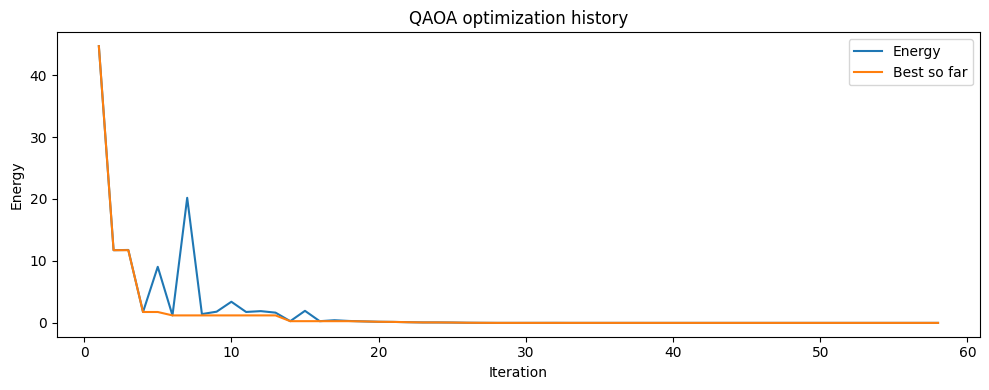

In [23]:
if len(history_df):
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["iteration"], history_df["energy"], label="Energy")
    plt.plot(history_df["iteration"], history_df["best_energy"], label="Best so far")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("QAOA optimization history")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [24]:
classical_pool = classical_results.head(OVERVIEW_CLASSICAL_POOL).copy() if len(classical_results) else classical_results.copy()
qaoa_pool = samples_df.head(OVERVIEW_QAOA_POOL).copy() if len(samples_df) else samples_df.copy()

combined_frames = []
if len(classical_pool):
    combined_frames.append(classical_pool[candidate_cols])
if len(qaoa_pool):
    combined_frames.append(qaoa_pool[candidate_cols])

combined = pd.concat(combined_frames, ignore_index=True) if len(combined_frames) else pd.DataFrame(columns=candidate_cols)
combined = sort_candidates(combined).drop_duplicates(subset=["bitstring"], keep="first").reset_index(drop=True)

overview_df = sort_candidates(combined).head(TOP_N_EXPORT).copy()
overview_df.insert(0, "rank", range(1, len(overview_df) + 1))
display(overview_df)

,rank,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,1,111111100000000000010000,classical_heuristic,NaN,0.476629,-0.099350,0.575978,7.849529e-07,0.0,0.476629,...,0.0,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897
1,2,010111100000100000011000,classical_heuristic,NaN,0.557828,-0.147247,0.705075,6.565252e-08,0.0,0.557828,...,0.0,1.000036e+06,36.236038,36.236038,8,7,0.870903,0.218490,3.802939,150061.090897
2,3,001110011100000000110000,classical_heuristic,NaN,0.562913,-0.325547,0.888457,2.598692e-06,0.0,0.562913,...,0.0,1.000228e+06,227.977722,227.977722,8,5,1.876679,0.245216,7.490055,150050.726257
3,4,111111100000000000100000,classical_heuristic,NaN,0.567778,-0.094717,0.538103,1.243922e-01,0.0,0.567778,...,0.0,9.501217e+05,-49878.297684,49878.297684,8,5,0.602557,0.200901,2.800166,150061.090897
4,5,111111100100000000000000,classical_heuristic,NaN,0.569859,-0.235445,0.805304,5.986278e-07,0.0,0.569859,...,0.0,1.000109e+06,109.419174,109.419174,8,5,1.368499,0.233486,5.689835,150061.090897
5,6,011101000000101000010010,classical_heuristic,NaN,0.571195,-0.180700,0.751885,9.441138e-06,0.0,0.571195,...,0.0,9.995655e+05,-434.537399,434.537399,8,7,1.060151,0.225732,4.519297,150061.090897
6,7,111110001000000001010000,classical_heuristic,NaN,0.572005,-0.242303,0.814301,6.862393e-06,0.0,0.572005,...,0.0,1.000370e+06,370.469772,370.469772,8,6,1.406838,0.234726,5.823130,150061.090897
7,8,111111100000000000000100,classical_heuristic,NaN,0.577430,-0.134722,0.712149,2.833101e-06,0.0,0.577430,...,0.0,1.000238e+06,238.037857,238.037857,8,5,0.800071,0.219539,3.462128,150123.522675
8,9,111101000000000001101000,classical_heuristic,NaN,0.578009,-0.171600,0.749608,5.006238e-07,0.0,0.578009,...,0.0,1.000100e+06,100.062363,100.062363,8,6,1.008262,0.225270,4.298234,150061.090897
9,10,111111100000000000000001,classical_heuristic,NaN,0.587617,-0.131920,0.719511,2.581727e-05,0.0,0.587617,...,0.0,1.000719e+06,718.571823,718.571823,8,5,0.783906,0.220565,3.372735,150604.056641


In [25]:
print("options_df created:", options_df.shape)

options_df created: (24, 15)


In [26]:
exploded_rows = []
for _, row in overview_df.iterrows():
    bitstring = row["bitstring"]
    source = row["source"]
    rank = int(row["rank"])
    bitvec = np.array(list(map(int, bitstring)), dtype=int)
    exploded_rows.extend(
        exploded_portfolio_rows(
            rank, source, bitstring, bitvec,
            options_df, Q, constant, qubo_meta,
            opt_tickers, opt_cost, opt_ret, Sigma_opt,
            risk_free, budget_usd
        )
    )

portfolios_df = pd.DataFrame(exploded_rows)
display(portfolios_df.head(40))

,rank,source,bitstring,Ticker,Company,Option Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,...,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd,qubo_value
0,1,classical_heuristic,111111100000000000010000,NVDA,NVIDIA,100k,498,100040.727264,0.979824,0.340606,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
1,1,classical_heuristic,111111100000000000010000,NVDA,NVIDIA,150k,747,150061.090897,0.979824,0.340606,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
2,1,classical_heuristic,111111100000000000010000,AAPL,Apple,100k,372,100033.817505,0.371104,0.235630,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
3,1,classical_heuristic,111111100000000000010000,AAPL,Apple,150k,558,150050.726257,0.371104,0.235630,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
4,1,classical_heuristic,111111100000000000010000,MSFT,Microsoft,100k,236,100143.554932,0.162612,0.245081,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
5,1,classical_heuristic,111111100000000000010000,MSFT,Microsoft,150k,353,149790.995300,0.162612,0.245081,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
6,1,classical_heuristic,111111100000000000010000,AVGO,Broadcom,100k,248,99993.603027,1.377139,0.427222,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
7,1,classical_heuristic,111111100000000000010000,CSCO,Cisco,150k,1761,150010.780701,0.562872,0.252707,...,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897,0.476629
8,2,classical_heuristic,010111100000100000011000,NVDA,NVIDIA,150k,747,150061.090897,0.979824,0.340606,...,1.000036e+06,36.236038,36.236038,8,7,0.870903,0.218490,3.802939,150061.090897,0.557828
9,2,classical_heuristic,010111100000100000011000,AAPL,Apple,150k,558,150050.726257,0.371104,0.235630,...,1.000036e+06,36.236038,36.236038,8,7,0.870903,0.218490,3.802939,150061.090897,0.557828


In [27]:
solver_frames = []
if len(classical_results):
    best_classical = sort_candidates(classical_results).head(1).copy()
    solver_frames.append(best_classical.assign(solver="Classical Heuristic"))

if len(samples_df):
    best_qaoa = sort_candidates(samples_df).head(1).copy()
    solver_frames.append(best_qaoa.assign(solver=f"QAOA PennyLane p={QAOA_P} ({qaoa_mode})"))

solver_comparison_df = pd.concat(solver_frames, ignore_index=True) if len(solver_frames) else pd.DataFrame()
if len(solver_comparison_df):
    solver_comparison_df = solver_comparison_df[[
        "solver", "bitstring", "qubo_value",
        "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
        "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
        "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
        "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
    ]]
display(solver_comparison_df)

,solver,bitstring,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,avg_risk_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,Classical Heuristic,111111100000000000010000,0.476629,-0.099350,0.575978,7.849529e-07,0.0,0.476629,-0.012419,0.071997,...,0.0,1.000125e+06,125.295883,125.295883,8,5,0.600572,0.197459,2.838926,150061.090897
1,QAOA PennyLane p=2 (exact_probs),010111000100000000110010,0.645617,-0.243187,0.764412,1.243918e-01,0.0,0.645617,-0.030398,0.095552,...,0.0,1.049878e+06,49878.206985,49878.206985,8,6,1.347133,0.216697,6.032063,150061.090897


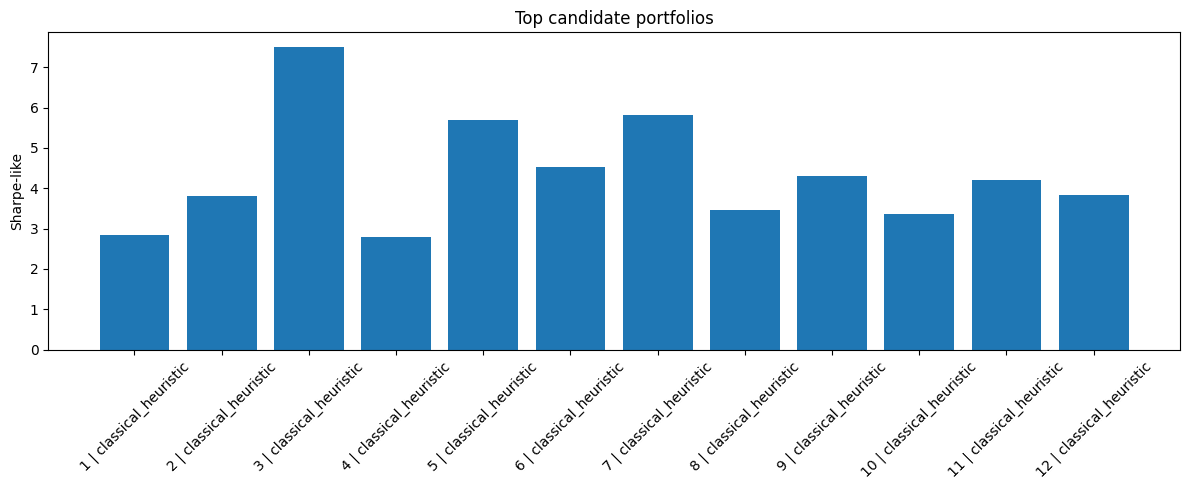

In [28]:
top_plot = overview_df.head(12).copy()
if len(top_plot):
    labels = top_plot["rank"].astype(str) + " | " + top_plot["source"].astype(str)

    plt.figure(figsize=(12, 5))
    plt.bar(labels, top_plot["sharpe_like"])
    plt.xticks(rotation=45)
    plt.ylabel("Sharpe-like")
    plt.title("Top candidate portfolios")
    plt.tight_layout()
    plt.show()

In [29]:
def write_df(ws, df, dark_fill, white_bold):
    for j, col in enumerate(df.columns, start=1):
        ws.cell(1, j, col)
        ws.cell(1, j).fill = dark_fill
        ws.cell(1, j).font = white_bold
    for i, row in enumerate(df.itertuples(index=False), start=2):
        for j, val in enumerate(row, start=1):
            ws.cell(i, j, val)

def write_results(xlsx_path, overview_df, portfolios_df, solver_comparison_df, classical_results, samples_df, history_df, best_gammas, best_betas, qaoa_p, qaoa_mode):
    wb = load_workbook(xlsx_path)

    for name in ["Results_Summary", "Results_Overview", "Results_Portfolios", "QAOA_Samples", "Classical_Candidates", "Solver_Comparison", "Optimization_History"]:
        if name in wb.sheetnames:
            wb.remove(wb[name])

    dark = PatternFill("solid", fgColor="1F4E78")
    white_bold = Font(color="FFFFFF", bold=True)

    summary_ws = wb.create_sheet("Results_Summary")
    summary_ws["A1"] = "Results summary"
    summary_ws["A1"].fill = dark
    summary_ws["A1"].font = white_bold

    summary_items = [
        ("Top-N exported", int(len(overview_df))),
        ("Classical candidate count", int(len(classical_results))),
        ("QAOA candidate count", int(len(samples_df))),
        ("QAOA enabled", int(ENABLE_QAOA)),
        ("QAOA p", int(qaoa_p)),
        ("QAOA mode", qaoa_mode),
        ("QAOA export mode", QAOA_EXPORT_MODE),
        ("QAOA export sort by", QAOA_EXPORT_SORT_BY),
        ("QAOA min probability to export", float(QAOA_MIN_PROBABILITY_TO_EXPORT)),
        ("QAOA max export rows", int(QAOA_MAX_EXPORT_ROWS)),
        ("QAOA feasible only", int(QAOA_EXPORT_FEASIBLE_ONLY)),
        ("QAOA feasibility budget tolerance USD", float(QAOA_FEASIBILITY_BUDGET_TOLERANCE_USD)),
        ("Decision variables", int(n)),
        ("Unique tickers", int(len(asset_universe))),
        ("QAOA total states considered", int(qaoa_total_states_considered)),
        ("QAOA nonzero states encountered", int(qaoa_total_nonzero_states)),
    ]
    summary_items += [(f"QAOA gamma_{i+1}", float(best_gammas[i]) if i < len(best_gammas) and np.isfinite(best_gammas[i]) else None) for i in range(qaoa_p)]
    summary_items += [(f"QAOA beta_{i+1}", float(best_betas[i]) if i < len(best_betas) and np.isfinite(best_betas[i]) else None) for i in range(qaoa_p)]
    summary_items += [
        ("Best overview Sharpe-like", float(overview_df["sharpe_like"].max()) if len(overview_df) else None),
        ("Best overview invested USD", float(overview_df.iloc[0]["selected_usd"]) if len(overview_df) else None),
        ("Best overview abs budget gap", float(overview_df.iloc[0]["abs_budget_gap"]) if len(overview_df) else None),
        ("Best overview return term", float(overview_df.iloc[0]["return_term"]) if len(overview_df) else None),
        ("Best overview risk term", float(overview_df.iloc[0]["risk_term"]) if len(overview_df) else None),
        ("Best overview budget term", float(overview_df.iloc[0]["budget_term"]) if len(overview_df) else None),
        ("Best overview exclusivity term", float(overview_df.iloc[0]["exclusivity_term"]) if len(overview_df) else None),
        ("Optimization iterations", int(len(history_df))),
    ]
    for i, (label, value) in enumerate(summary_items, start=2):
        summary_ws.cell(i, 1, label)
        summary_ws.cell(i, 2, value)

    overview_ws = wb.create_sheet("Results_Overview")
    write_df(overview_ws, overview_df, dark, white_bold)

    portfolios_ws = wb.create_sheet("Results_Portfolios")
    write_df(portfolios_ws, portfolios_df, dark, white_bold)

    qaoa_ws = wb.create_sheet("QAOA_Samples")
    write_df(qaoa_ws, samples_df.head(RESULT_CANDIDATE_LIMIT_PER_SOLVER), dark, white_bold)

    classical_ws = wb.create_sheet("Classical_Candidates")
    write_df(classical_ws, classical_results.head(RESULT_CANDIDATE_LIMIT_PER_SOLVER), dark, white_bold)

    solver_ws = wb.create_sheet("Solver_Comparison")
    write_df(solver_ws, solver_comparison_df, dark, white_bold)

    history_ws = wb.create_sheet("Optimization_History")
    write_df(history_ws, history_df, dark, white_bold)

    wb.save(xlsx_path)
    print(f"Results written to {xlsx_path.resolve()}")

write_results(
    xlsx_path=xlsx_path,
    overview_df=overview_df,
    portfolios_df=portfolios_df,
    solver_comparison_df=solver_comparison_df,
    classical_results=classical_results,
    samples_df=samples_df,
    history_df=history_df,
    best_gammas=best_gammas,
    best_betas=best_betas,
    qaoa_p=QAOA_P,
    qaoa_mode=qaoa_mode,
)

Results written to /Users/danielhug/code/qubit-lab/QAOA-Optimizer/Version 3/parametric_assets_only_input_extended.xlsx
